In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training Images Shape:", x_train.shape)   # (50000, 32, 32, 3)
print("Training Labels Shape:", y_train.shape)   # (50000, 1)
print("Testing Images Shape :", x_test.shape)    # (10000, 32, 32, 3)
print("Testing Labels Shape :", y_test.shape)    # (10000, 1)
print("Number of Classes    :", len(class_names))
print("Image Size           : 32 x 32 x 3")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1655s 10us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)
Number of Classes    : 10
Image Size           : 32 x 32 x 3


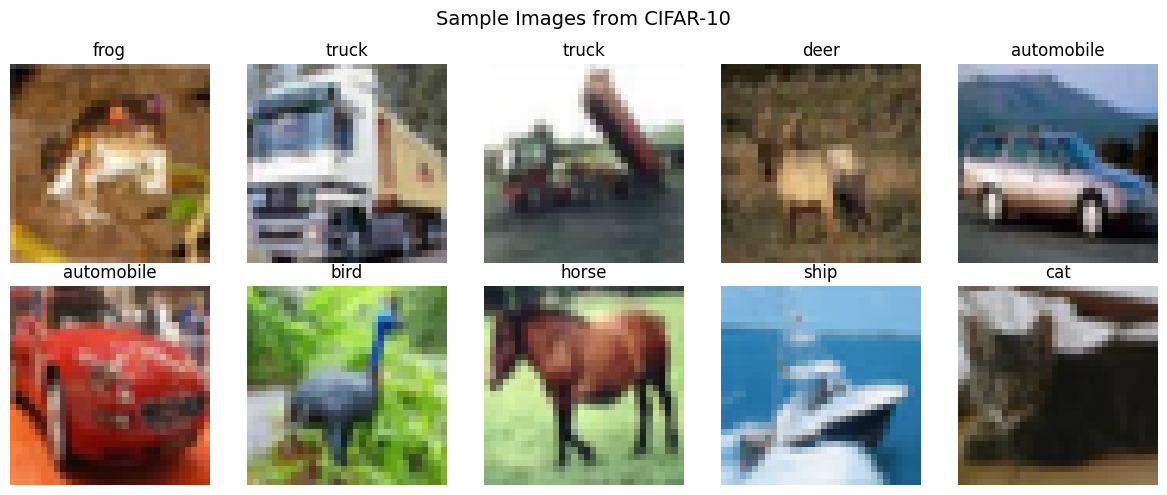

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_23/746029888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")


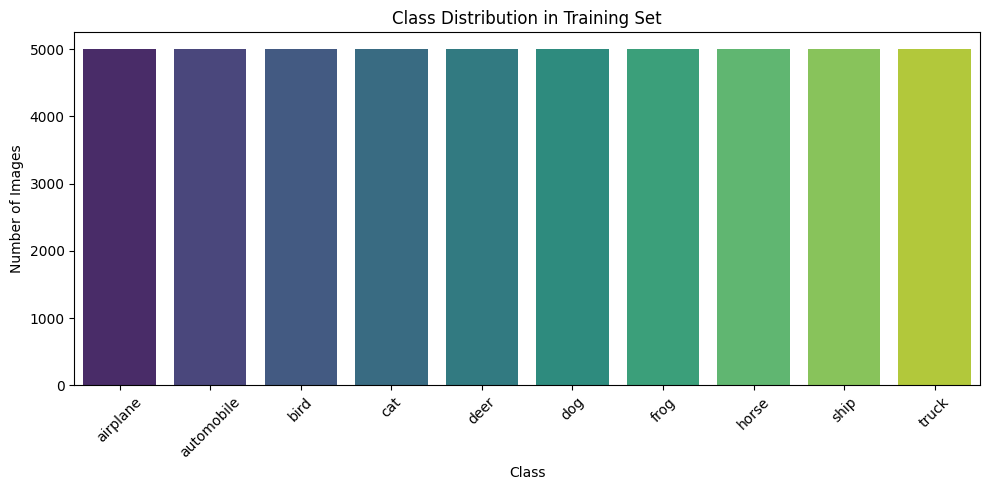

Class-wise counts:
airplane    : 5000
automobile  : 5000
bird        : 5000
cat         : 5000
deer        : 5000
dog         : 5000
frog        : 5000
horse       : 5000
ship        : 5000
truck       : 5000


In [4]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Class-wise counts:")
for i, c in zip(unique, counts):
    print(f"{class_names[i]:12s}: {c}")

In [5]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("x_train_norm shape:", x_train_norm.shape)
print("y_train_cat shape :", y_train_cat.shape)

input_sample = x_train_norm[0:1]

x_train_norm shape: (50000, 32, 32, 3)
y_train_cat shape : (50000, 10)


In [6]:
kernel_sizes = [3, 5, 7]
print(f"Input shape: {input_sample.shape}\n")

for k in kernel_sizes:
    conv_layer = layers.Conv2D(filters=8, kernel_size=k, strides=1, padding='valid')
    output = conv_layer(input_sample)
    print(f"Kernel Size = {k}x{k} -> Output Feature Map Shape: {output.shape}")

Input shape: (1, 32, 32, 3)



I0000 00:00:1785950914.726718      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785950914.729535      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Kernel Size = 3x3 -> Output Feature Map Shape: (1, 30, 30, 8)
Kernel Size = 5x5 -> Output Feature Map Shape: (1, 28, 28, 8)
Kernel Size = 7x7 -> Output Feature Map Shape: (1, 26, 26, 8)


In [7]:
configs = [
    {"stride": 1, "padding": "same"},
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "same"},
    {"stride": 2, "padding": "valid"},
]

print(f"Input shape: {input_sample.shape}\n")

for cfg in configs:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3,
                                strides=cfg["stride"], padding=cfg["padding"])
    output = conv_layer(input_sample)
    print(f"Stride={cfg['stride']}, Padding={cfg['padding']:5s} -> Output Shape: {output.shape}")

Input shape: (1, 32, 32, 3)

Stride=1, Padding=same  -> Output Shape: (1, 32, 32, 8)
Stride=1, Padding=valid -> Output Shape: (1, 30, 30, 8)
Stride=2, Padding=same  -> Output Shape: (1, 16, 16, 8)
Stride=2, Padding=valid -> Output Shape: (1, 15, 15, 8)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


I0000 00:00:1785950920.874678      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Feature map shape: (1, 32, 32, 32)


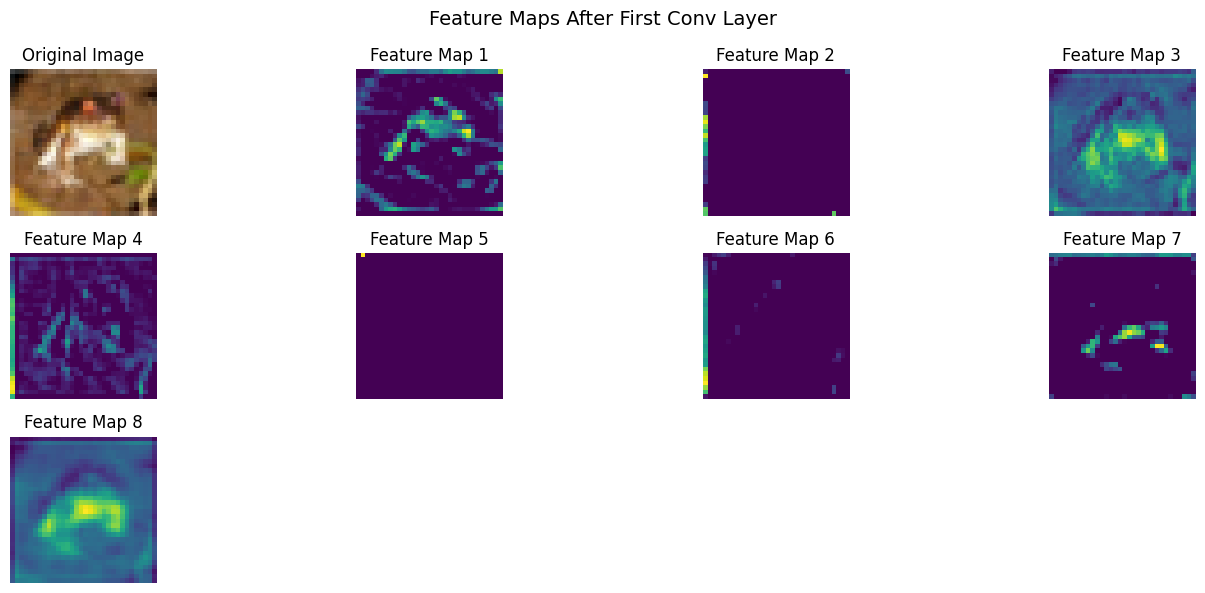

In [8]:
feature_map_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3))
])

sample_image = x_train_norm[0:1]
feature_maps = feature_map_model.predict(sample_image)
print("Feature map shape:", feature_maps.shape)  # (1, 32, 32, 32)

plt.figure(figsize=(14, 6))
plt.subplot(3, 4, 1)
plt.imshow(x_train[0])
plt.title("Original Image")
plt.axis('off')

for i in range(8):
    plt.subplot(3, 4, i + 2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Feature Map {i+1}")
    plt.axis('off')

plt.suptitle("Feature Maps After First Conv Layer", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
def build_pooling_model(pooling_type='max'):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    if pooling_type == 'max':
        model.add(layers.MaxPooling2D((2, 2)))
    else:
        model.add(layers.AveragePooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    if pooling_type == 'max':
        model.add(layers.MaxPooling2D((2, 2)))
    else:
        model.add(layers.AveragePooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    return model

pooling_results = {}

for pool_type in ['max', 'average']:
    print(f"\n--- Training with {pool_type.upper()} Pooling ---")
    pmodel = build_pooling_model(pool_type)
    pmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    sample_out = pmodel.layers[0](input_sample)
    pool_out = pmodel.layers[1](sample_out)
    print(f"Output shape after first {pool_type} pooling layer: {pool_out.shape}")

    history_pool = pmodel.fit(x_train_norm, y_train_cat, epochs=3, batch_size=64,
                               validation_split=0.1, verbose=1)

    test_loss, test_acc = pmodel.evaluate(x_test_norm, y_test_cat, verbose=0)
    pooling_results[pool_type] = test_acc
    print(f"{pool_type.upper()} Pooling Test Accuracy: {test_acc:.4f}")

print("\nPooling Comparison Summary:")
for k, v in pooling_results.items():
    print(f"{k.capitalize()} Pooling Accuracy: {v:.4f}")


--- Training with MAX Pooling ---
Output shape after first max pooling layer: (1, 16, 16, 32)
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4665 - loss: 1.4958 - val_accuracy: 0.5738 - val_loss: 1.2152
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6097 - loss: 1.1152 - val_accuracy: 0.6194 - val_loss: 1.0780
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6577 - loss: 0.9826 - val_accuracy: 0.6518 - val_loss: 1.0100
MAX Pooling Test Accuracy: 0.6411

--- Training with AVERAGE Pooling ---
Output shape after first average pooling layer: (1, 16, 16, 32)
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4296 - loss: 1.5896 - val_accuracy: 0.5114 - val_loss: 1.3440
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5489 - loss: 1.2709 - val_accuracy: 0.5740 - val_loss: 1.2107
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6043 - loss: 1.1252 - val_accuracy: 0.6300 - val_loss: 1.0641
AVERAG

In [10]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    x_train_norm, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(x_test_norm, y_test_cat),
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5073 - loss: 1.3858 - val_accuracy: 0.5878 - val_loss: 1.1403
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6455 - loss: 1.0156 - val_accuracy: 0.6180 - val_loss: 1.0824
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6910 - loss: 0.8826 - val_accuracy: 0.6750 - val_loss: 0.9335
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7259 - loss: 0.7846 - val_accuracy: 0.6907 - val_loss: 0.8962
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7531 - loss: 0.7011 - val_accuracy: 0.7006 - val_loss: 0.8777
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7778 - loss: 0.6287 - val_accuracy: 0.7011 - val_loss: 0.8776
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8035 - loss: 0.5593 - val_accuracy: 0.6883 - val_loss: 0.9645
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8253 - loss: 0.4947 -

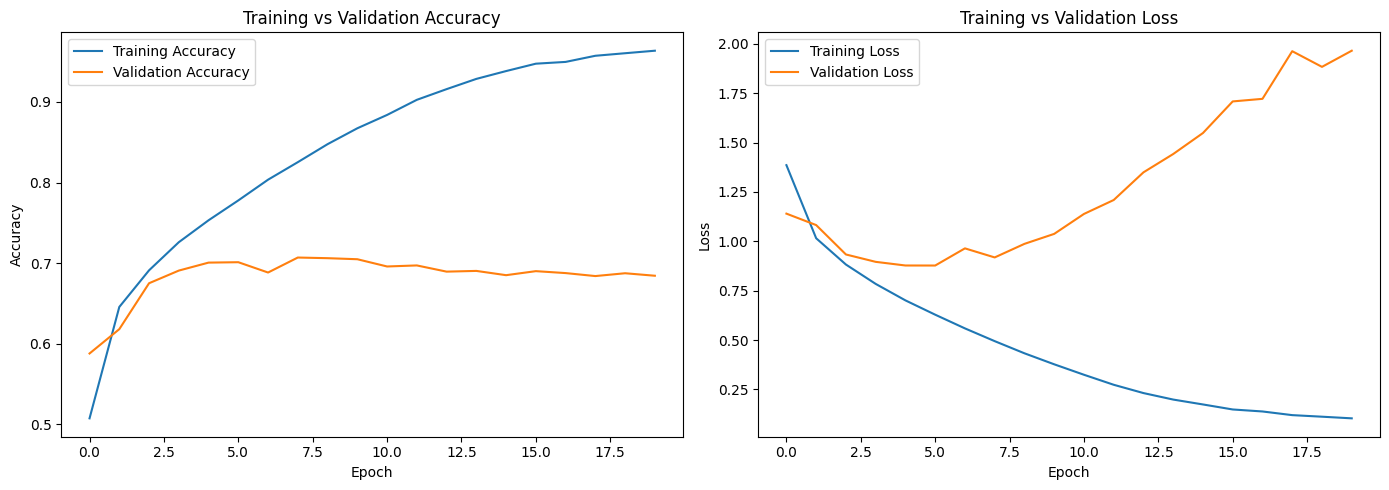

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy  : 0.6843
Precision : 0.6864
Recall    : 0.6843
F1-score  : 0.6844

Classification Report:

              precision    recall  f1-score   support

    airplane       0.68      0.78      0.73      1000
  automobile       0.83      0.76      0.79      1000
        bird       0.57      0.58      0.58      1000
         cat       0.52      0.45      0.48      1000
        deer       0.63      0.65      0.64      1000
         dog       0.56      0.62      0.59      1000
        frog       0.74      0.73      0.74      1000
       horse       0.75      0.74      0.75      1000
        ship       0.82      0.78      0.80      1000
       truck       0.76      0.75      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



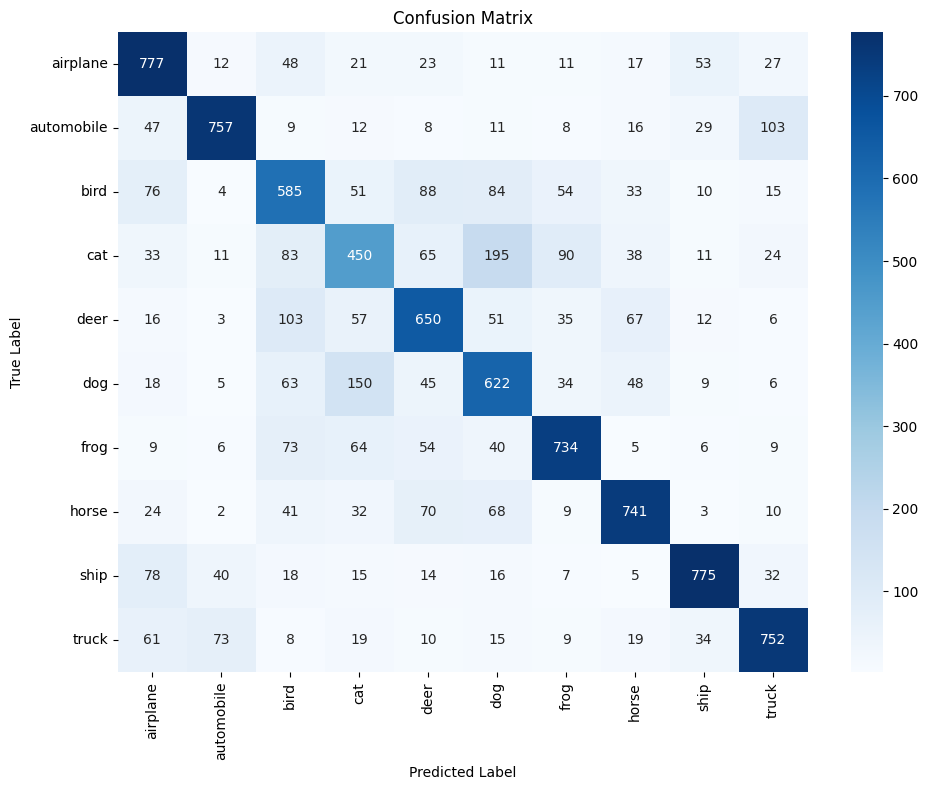

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()